# 10 — Cross-Dataset Generalization
**Project:** Quantum Machine Learning for Physiological Stress Classification  
**Author:** Kenza Qribis

---

## Purpose
Evaluate how well models trained on one dataset generalize to the other.
This tests whether learned stress representations transfer across different
sensor modalities and stimulus protocols.

## Experiment Design
Since WESAD (peripheral signals) and DREAMER (EEG) have different feature spaces,
cross-dataset generalization uses **shared features only** — the ECG/HRV features
that exist in both datasets:
- ecg_mean_hr, ecg_sdnn, ecg_rmssd, ecg_pnn50, ecg_mean_rr

## Directions
1. **WESAD → DREAMER**: Train on all WESAD subjects, test on all DREAMER subjects
2. **DREAMER → WESAD**: Train on all DREAMER subjects, test on all WESAD subjects

## Label Alignment
- WESAD binary label: baseline(0) vs stress(1)
- DREAMER binary label: low arousal(0) vs high arousal/stress-proxy(1)
Both are binarized stress proxies — imperfect alignment is expected and
is itself a research finding about cross-dataset transferability.

## Models Evaluated
All classical and best quantum configurations from previous notebooks.

---


## 0. Configuration

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

from qiskit.circuit.library import ZZFeatureMap, PauliFeatureMap
from qiskit_machine_learning.kernels import FidelityStatevectorKernel

warnings.filterwarnings('ignore')

RESULTS_ROOT    = os.path.join('..', 'results')
PLOTS_DIR       = os.path.join(RESULTS_ROOT, 'plots', '10_cross_dataset')
LOGS_DIR        = os.path.join(RESULTS_ROOT, 'logs')
OUTPUT_DATA_DIR = os.path.join(RESULTS_ROOT, 'output_data')
for d in [PLOTS_DIR, LOGS_DIR, OUTPUT_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

RANDOM_STATE        = 42
N_SAMPLES_PER_CLASS = 150
N_QUBITS_CROSS      = 3    # limited by shared feature count

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('Configuration ready.')


Configuration ready.


## 1. Load Datasets & Identify Shared Features

In [2]:
# Load WESAD binary
df_wesad = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'wesad_features_binary.csv'))
wesad_all_feats = json.load(
    open(os.path.join(OUTPUT_DATA_DIR, 'feature_columns.json')))

# Load DREAMER binary
df_dreamer = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'dreamer_features_binary.csv'))
dreamer_all_feats = json.load(
    open(os.path.join(OUTPUT_DATA_DIR, 'dreamer_feature_columns.json')))

# Fix DREAMER ratings if needed
if len(df_dreamer) == 0 or df_dreamer['arousal_binary'].isna().all():
    from scipy.io import loadmat
    DREAMER_PATH = r"C:/path/to/DREAMER/DREAMER.mat"
    mat = loadmat(DREAMER_PATH, simplify_cells=True)
    data_all = mat['DREAMER']['Data']
    rows = []
    for sid in range(23):
        s = data_all[sid]
        aro = np.array(s['ScoreArousal']).flatten()
        val = np.array(s['ScoreValence']).flatten()
        for vid in range(len(aro)):
            rows.append({'subject_id': sid+1, 'video_id': vid+1,
                         'arousal': float(aro[vid]),
                         'arousal_binary': int(aro[vid] > 3),
                         'valence': float(val[vid])})
    df_r = pd.DataFrame(rows)
    df_dreamer_full = pd.read_csv(
        os.path.join(OUTPUT_DATA_DIR, 'dreamer_features_all.csv'))
    for c in ['arousal','arousal_binary','valence']:
        if c in df_dreamer_full.columns:
            df_dreamer_full = df_dreamer_full.drop(columns=[c])
    df_dreamer = df_dreamer_full.merge(
        df_r[['subject_id','video_id','arousal','arousal_binary','valence']],
        on=['subject_id','video_id'], how='left')
    df_dreamer = df_dreamer.dropna(subset=['arousal_binary']).copy()
    df_dreamer['arousal_binary'] = df_dreamer['arousal_binary'].astype(int)
    df_dreamer.to_csv(
        os.path.join(OUTPUT_DATA_DIR, 'dreamer_features_binary.csv'),
        index=False)
    print('DREAMER ratings fixed.')

# Remove all-NaN WESAD features
wesad_all_feats = [c for c in wesad_all_feats
                   if not df_wesad[c].isna().all()]

# Identify shared features — ECG/HRV present in both
wesad_set   = set(wesad_all_feats)
dreamer_set = set(dreamer_all_feats)
shared_feats = sorted(wesad_set & dreamer_set)

# If no overlap found, use ECG features explicitly
if len(shared_feats) == 0:
    ecg_feats = ['ecg_mean_hr','ecg_sdnn','ecg_rmssd',
                 'ecg_pnn50','ecg_mean_rr']
    shared_feats = [f for f in ecg_feats
                    if f in df_wesad.columns and f in df_dreamer.columns]

print(f'WESAD features    : {len(wesad_all_feats)}')
print(f'DREAMER features  : {len(dreamer_all_feats)}')
print(f'Shared features   : {len(shared_feats)}')
print(f'Shared            : {shared_feats}')

# Update N_QUBITS to match shared feature count (max 5)
N_QUBITS_CROSS = min(len(shared_feats), 5)
print(f'\nQubits for cross-dataset QSVM: {N_QUBITS_CROSS}')


WESAD features    : 22
DREAMER features  : 139
Shared features   : 5
Shared            : ['ecg_mean_hr', 'ecg_mean_rr', 'ecg_pnn50', 'ecg_rmssd', 'ecg_sdnn']

Qubits for cross-dataset QSVM: 5


## 2. Utilities

In [3]:
def preprocess(X_train, X_test, n_qubits=None):
    """
    Impute -> RobustScale -> optional PCA -> MinMax(-pi,pi).
    All fitted on train only.
    """
    imp     = SimpleImputer(strategy='median')
    X_train = imp.fit_transform(X_train)
    X_test  = imp.transform(X_test)

    scaler  = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    if n_qubits is not None and n_qubits < X_train.shape[1]:
        pca     = PCA(n_components=n_qubits, random_state=RANDOM_STATE)
        X_train = pca.fit_transform(X_train)
        X_test  = pca.transform(X_test)
        mm      = MinMaxScaler(feature_range=(-np.pi, np.pi))
        X_train = mm.fit_transform(X_train)
        X_test  = mm.transform(X_test)

    return X_train, X_test


def stratified_subsample(X, y, n, rs=RANDOM_STATE):
    rng = np.random.RandomState(rs)
    parts_X, parts_y = [], []
    for cls in np.unique(y):
        idx = np.where(y==cls)[0]
        chosen = idx if len(idx)<=n else rng.choice(idx, n, replace=False)
        parts_X.append(X[chosen])
        parts_y.append(y[chosen])
    X_out = np.vstack(parts_X)
    y_out = np.concatenate(parts_y)
    perm  = rng.permutation(len(y_out))
    return X_out[perm], y_out[perm]


def compute_metrics(y_true, y_pred):
    return {
        'accuracy' : float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred,
                           average='macro', zero_division=0)),
        'recall'   : float(recall_score(y_true, y_pred,
                           average='macro', zero_division=0)),
        'f1'       : float(f1_score(y_true, y_pred,
                           average='macro', zero_division=0)),
    }


print('Utilities defined.')


Utilities defined.


## 3. Classical Models — Cross-Dataset
Train on full WESAD → test on full DREAMER, and vice versa.

In [4]:
def run_cross_classical(df_train, label_train, df_test, label_test,
                        feat_cols, direction):
    """
    Train on one dataset, test on the other.
    No LOSO — single train/test split across datasets.
    """
    X_train = df_train[feat_cols].values.astype(float)
    y_train = df_train[label_train].values
    X_test  = df_test[feat_cols].values.astype(float)
    y_test  = df_test[label_test].values

    X_train, X_test = preprocess(X_train, X_test)

    # Subsample train to balance classes
    X_train, y_train = stratified_subsample(
        X_train, y_train, N_SAMPLES_PER_CLASS)

    models = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, class_weight='balanced',
            random_state=RANDOM_STATE),
        'SVM (RBF)': SVC(
            kernel='rbf', class_weight='balanced',
            random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1),
    }

    rows = []
    for name, model in models.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0
        y_pred = model.predict(X_test)
        metrics = compute_metrics(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        rows.append({
            'direction'  : direction,
            'model'      : name,
            'train_size' : len(y_train),
            'test_size'  : len(y_test),
            'train_time' : round(train_time, 4),
            **metrics
        })
        print(f'  {name:22s}: acc={metrics["accuracy"]:.3f}  '
              f'f1={metrics["f1"]:.3f}')

    return pd.DataFrame(rows)


print('=== Direction 1: WESAD -> DREAMER ===')
print(f'  Train: {len(df_wesad)} WESAD windows  '
      f'Test: {len(df_dreamer)} DREAMER recordings')
print(f'  Shared features: {shared_feats}')
results_w2d = run_cross_classical(
    df_train=df_wesad,   label_train='label_encoded',
    df_test=df_dreamer,  label_test='arousal_binary',
    feat_cols=shared_feats,
    direction='WESAD->DREAMER')

print('\n=== Direction 2: DREAMER -> WESAD ===')
print(f'  Train: {len(df_dreamer)} DREAMER recordings  '
      f'Test: {len(df_wesad)} WESAD windows')
results_d2w = run_cross_classical(
    df_train=df_dreamer, label_train='arousal_binary',
    df_test=df_wesad,    label_test='label_encoded',
    feat_cols=shared_feats,
    direction='DREAMER->WESAD')

df_cross_classical = pd.concat([results_w2d, results_d2w],
                                 ignore_index=True)
print('\n=== Cross-Dataset Classical Summary ===')
print(df_cross_classical[['direction','model','accuracy',
                           'f1']].to_string(index=False))


=== Direction 1: WESAD -> DREAMER ===
  Train: 883 WESAD windows  Test: 414 DREAMER recordings
  Shared features: ['ecg_mean_hr', 'ecg_mean_rr', 'ecg_pnn50', 'ecg_rmssd', 'ecg_sdnn']
  Logistic Regression   : acc=0.553  f1=0.419
  SVM (RBF)             : acc=0.558  f1=0.399
  Random Forest         : acc=0.565  f1=0.436

=== Direction 2: DREAMER -> WESAD ===
  Train: 414 DREAMER recordings  Test: 883 WESAD windows
  Logistic Regression   : acc=0.539  f1=0.539
  SVM (RBF)             : acc=0.462  f1=0.460
  Random Forest         : acc=0.536  f1=0.525

=== Cross-Dataset Classical Summary ===
     direction               model  accuracy       f1
WESAD->DREAMER Logistic Regression  0.553140 0.418870
WESAD->DREAMER           SVM (RBF)  0.557971 0.398843
WESAD->DREAMER       Random Forest  0.565217 0.436275
DREAMER->WESAD Logistic Regression  0.539071 0.538671
DREAMER->WESAD           SVM (RBF)  0.462061 0.459730
DREAMER->WESAD       Random Forest  0.535674 0.524561


## 4. QSVM — Cross-Dataset
Uses best QSVM config from notebook 07: RobustScaler + PauliFeatureMap + circular.

In [5]:
def run_cross_qsvm(df_train, label_train, df_test, label_test,
                   feat_cols, direction, n_qubits,
                   fm_name='PauliFeatureMap', entanglement='circular'):
    X_train = df_train[feat_cols].values.astype(float)
    y_train = df_train[label_train].values
    X_test  = df_test[feat_cols].values.astype(float)
    y_test  = df_test[label_test].values

    X_train, X_test = preprocess(X_train, X_test, n_qubits=n_qubits)
    X_train, y_train = stratified_subsample(
        X_train, y_train, N_SAMPLES_PER_CLASS)

    try:
        if fm_name == 'ZZFeatureMap':
            fm = ZZFeatureMap(feature_dimension=n_qubits,
                              reps=1, entanglement=entanglement)
        else:
            fm = PauliFeatureMap(feature_dimension=n_qubits,
                                 reps=1, entanglement=entanglement,
                                 paulis=['Z','ZZ'])

        kernel  = FidelityStatevectorKernel(feature_map=fm)
        t0      = time.time()
        K_train = kernel.evaluate(x_vec=X_train)
        K_test  = kernel.evaluate(x_vec=X_test, y_vec=X_train)
        svm     = SVC(kernel='precomputed', class_weight='balanced')
        svm.fit(K_train, y_train)
        train_time = time.time() - t0
        y_pred  = svm.predict(K_test)
        metrics = compute_metrics(y_test, y_pred)
        status  = 'ok'
    except Exception as e:
        metrics    = {'accuracy':np.nan,'precision':np.nan,
                      'recall':np.nan,'f1':np.nan}
        train_time = np.nan
        status     = str(e)[:60]

    print(f'  QSVM ({fm_name}, {entanglement}): '
          f'acc={metrics["accuracy"]:.3f}  f1={metrics["f1"]:.3f}  '
          f'status={status}')
    return {
        'direction'  : direction,
        'model'      : f'QSVM ({fm_name}, {entanglement})',
        'train_size' : len(y_train),
        'test_size'  : len(y_test),
        'train_time' : round(train_time, 2) if not np.isnan(train_time) else np.nan,
        **metrics
    }


print('=== QSVM Cross-Dataset ===')
qsvm_rows = []

for fm in ['ZZFeatureMap', 'PauliFeatureMap']:
    for direction, df_tr, lbl_tr, df_te, lbl_te in [
            ('WESAD->DREAMER', df_wesad,   'label_encoded',
             df_dreamer, 'arousal_binary'),
            ('DREAMER->WESAD', df_dreamer, 'arousal_binary',
             df_wesad,   'label_encoded')]:
        print(f'\n  {direction} | {fm}')
        row = run_cross_qsvm(
            df_tr, lbl_tr, df_te, lbl_te,
            feat_cols=shared_feats,
            direction=direction,
            n_qubits=N_QUBITS_CROSS,
            fm_name=fm, entanglement='circular')
        qsvm_rows.append(row)

df_cross_qsvm = pd.DataFrame(qsvm_rows)
print('\n=== Cross-Dataset QSVM Summary ===')
print(df_cross_qsvm[['direction','model','accuracy',
                      'f1']].to_string(index=False))


=== QSVM Cross-Dataset ===

  WESAD->DREAMER | ZZFeatureMap
  QSVM (ZZFeatureMap, circular): acc=0.543  f1=0.533  status=ok

  DREAMER->WESAD | ZZFeatureMap
  QSVM (ZZFeatureMap, circular): acc=0.473  f1=0.462  status=ok

  WESAD->DREAMER | PauliFeatureMap
  QSVM (PauliFeatureMap, circular): acc=0.543  f1=0.533  status=ok

  DREAMER->WESAD | PauliFeatureMap
  QSVM (PauliFeatureMap, circular): acc=0.473  f1=0.462  status=ok

=== Cross-Dataset QSVM Summary ===
     direction                            model  accuracy       f1
WESAD->DREAMER    QSVM (ZZFeatureMap, circular)  0.543478 0.532656
DREAMER->WESAD    QSVM (ZZFeatureMap, circular)  0.473386 0.462440
WESAD->DREAMER QSVM (PauliFeatureMap, circular)  0.543478 0.532656
DREAMER->WESAD QSVM (PauliFeatureMap, circular)  0.473386 0.462440


## 5. Combined Results & Analysis

In [6]:
# Combine all cross-dataset results
df_cross_all = pd.concat(
    [df_cross_classical, df_cross_qsvm],
    ignore_index=True)

print('=== FULL CROSS-DATASET RESULTS ===')
print(df_cross_all[['direction','model','accuracy','precision',
                     'recall','f1']].round(4).to_string(index=False))

# Save
p = os.path.join(OUTPUT_DATA_DIR, 'cross_dataset_results.csv')
df_cross_all.to_csv(p, index=False)
print(f'\nSaved: {p}')

# Key finding: compare WESAD->DREAMER vs DREAMER->WESAD
print('\n=== DIRECTIONAL COMPARISON ===')
for direction in ['WESAD->DREAMER', 'DREAMER->WESAD']:
    subset = df_cross_all[df_cross_all['direction']==direction]
    print(f'\n  {direction}:')
    print(f'  Best F1  : {subset["f1"].max():.4f} '
          f'({subset.loc[subset["f1"].idxmax(), "model"]})')
    print(f'  Mean F1  : {subset["f1"].mean():.4f}')
    print(f'  Worst F1 : {subset["f1"].min():.4f} '
          f'({subset.loc[subset["f1"].idxmin(), "model"]})')


=== FULL CROSS-DATASET RESULTS ===
     direction                            model  accuracy  precision  recall     f1
WESAD->DREAMER              Logistic Regression    0.5531     0.5022  0.5007 0.4189
WESAD->DREAMER                        SVM (RBF)    0.5580     0.5067  0.5013 0.3988
WESAD->DREAMER                    Random Forest    0.5652     0.5421  0.5132 0.4363
DREAMER->WESAD              Logistic Regression    0.5391     0.5770  0.5796 0.5387
DREAMER->WESAD                        SVM (RBF)    0.4621     0.5286  0.5257 0.4597
DREAMER->WESAD                    Random Forest    0.5357     0.5335  0.5366 0.5246
WESAD->DREAMER    QSVM (ZZFeatureMap, circular)    0.5435     0.5333  0.5328 0.5327
DREAMER->WESAD    QSVM (ZZFeatureMap, circular)    0.4734     0.4742  0.4718 0.4624
WESAD->DREAMER QSVM (PauliFeatureMap, circular)    0.5435     0.5333  0.5328 0.5327
DREAMER->WESAD QSVM (PauliFeatureMap, circular)    0.4734     0.4742  0.4718 0.4624

Saved: ..\results\output_data\cross_data

## 6. Plots

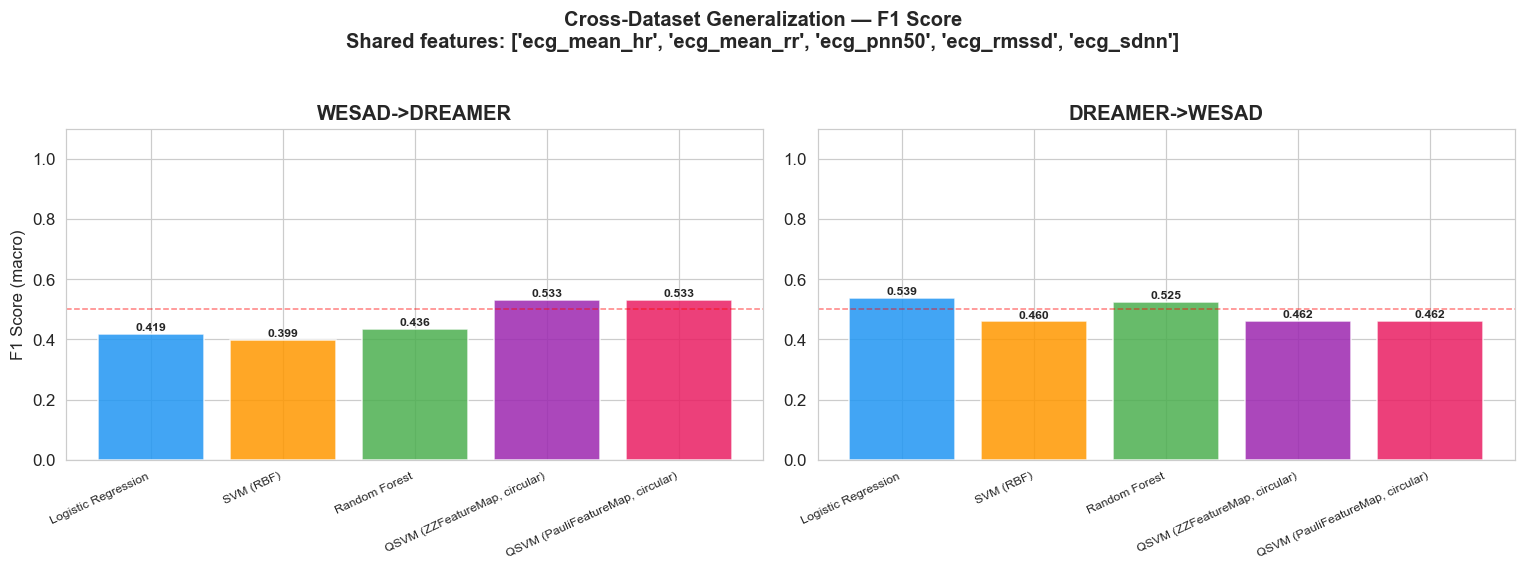

Saved: ..\results\plots\10_cross_dataset\cross_dataset_f1_comparison.png


In [7]:
# F1 comparison: WESAD->DREAMER vs DREAMER->WESAD
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {
    'Logistic Regression'  : '#2196F3',
    'SVM (RBF)'            : '#FF9800',
    'Random Forest'        : '#4CAF50',
    'QSVM (ZZFeatureMap, circular)'    : '#9C27B0',
    'QSVM (PauliFeatureMap, circular)' : '#E91E63',
}

for ax, direction in zip(axes, ['WESAD->DREAMER', 'DREAMER->WESAD']):
    subset = df_cross_all[df_cross_all['direction']==direction]
    models = subset['model'].tolist()
    f1s    = subset['f1'].tolist()
    clrs   = [colors.get(m, 'gray') for m in models]
    bars   = ax.bar(range(len(models)), f1s, color=clrs, alpha=0.85)
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.set_title(direction, fontweight='bold')
    ax.set_ylabel('F1 Score (macro)' if ax==axes[0] else '')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=25, ha='right', fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='red', linestyle='--', lw=1, alpha=0.5,
               label='chance')

plt.suptitle('Cross-Dataset Generalization — F1 Score\n'
             f'Shared features: {shared_feats}',
             fontweight='bold', y=1.03)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'cross_dataset_f1_comparison.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


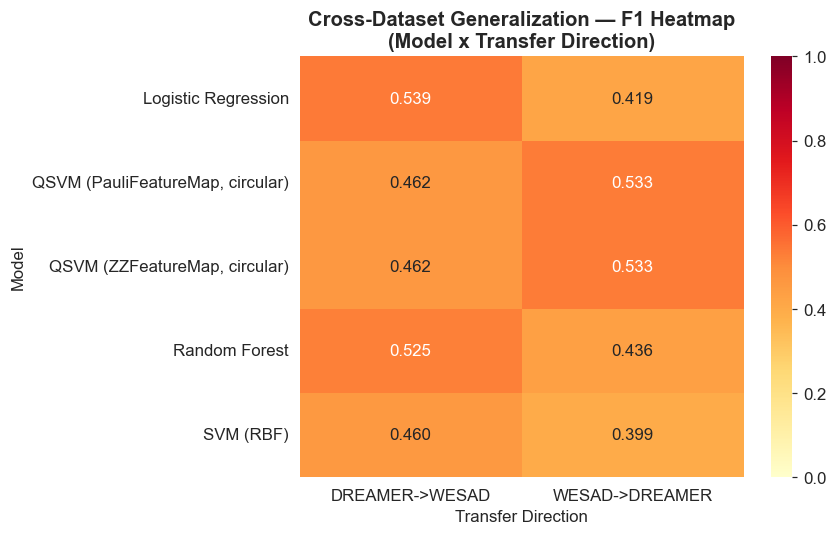

Saved: ..\results\plots\10_cross_dataset\cross_dataset_f1_heatmap.png


In [8]:
# Heatmap: model x direction
pivot = df_cross_all.pivot_table(
    index='model', columns='direction', values='f1')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=ax, vmin=0, vmax=1, annot_kws={'size':11})
ax.set_title('Cross-Dataset Generalization — F1 Heatmap\n'
             '(Model x Transfer Direction)',
             fontweight='bold')
ax.set_xlabel('Transfer Direction')
ax.set_ylabel('Model')
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'cross_dataset_f1_heatmap.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


In [9]:
# Within-dataset vs cross-dataset comparison for classical models
# Load within-dataset results from notebook 05
within_path = os.path.join(OUTPUT_DATA_DIR, 'classical_baselines_summary.csv')
if os.path.exists(within_path):
    df_within = pd.read_csv(within_path)

    # Get WESAD binary within-dataset F1
    wesad_within = df_within[
        df_within['task']=='WESAD_binary'][['model','f1_mean']].copy()
    wesad_within.columns = ['model','within_dataset_f1']

    # Get cross-dataset F1 (WESAD->DREAMER direction)
    cross_w2d = df_cross_classical[
        df_cross_classical['direction']=='WESAD->DREAMER'
    ][['model','f1']].copy()
    cross_w2d.columns = ['model','cross_dataset_f1']

    comparison = wesad_within.merge(cross_w2d, on='model', how='inner')
    comparison['f1_drop'] = (
        comparison['within_dataset_f1'] -
        comparison['cross_dataset_f1'])

    print('=== Within vs Cross-Dataset F1 (WESAD models) ===')
    print(comparison.round(4).to_string(index=False))
    print('\nF1 drop = performance lost when generalizing to DREAMER')

    p = os.path.join(OUTPUT_DATA_DIR, 'within_vs_cross_comparison.csv')
    comparison.to_csv(p, index=False)
    print(f'\nSaved: {p}')
else:
    print('classical_baselines_summary.csv not found.')
    print('Run notebook 05 first.')


=== Within vs Cross-Dataset F1 (WESAD models) ===
              model  within_dataset_f1  cross_dataset_f1  f1_drop
Logistic Regression             0.8197            0.4189   0.4008
      Random Forest             0.8769            0.4363   0.4406
          SVM (RBF)             0.8474            0.3988   0.4486

F1 drop = performance lost when generalizing to DREAMER

Saved: ..\results\output_data\within_vs_cross_comparison.csv


## 7. Summary Log

In [10]:
summary = {
    'notebook'       : '10_cross_dataset',
    'timestamp'      : datetime.now().isoformat(),
    'shared_features': shared_feats,
    'n_shared'       : len(shared_feats),
    'directions'     : ['WESAD->DREAMER', 'DREAMER->WESAD'],
    'models_evaluated': df_cross_all['model'].unique().tolist(),
    'results'        : {}
}

for _, row in df_cross_all.iterrows():
    key = f"{row['direction']}|{row['model']}"
    summary['results'][key] = {
        'f1'      : round(row['f1'], 4),
        'accuracy': round(row['accuracy'], 4),
    }

summary['next'] = '11_results_analysis.ipynb'

p = os.path.join(LOGS_DIR, '10_cross_dataset_summary.json')
with open(p,'w') as f: json.dump(summary, f, indent=2)

print('=' * 60)
print('CROSS-DATASET GENERALIZATION COMPLETE')
print('=' * 60)
print(json.dumps(summary, indent=2))
print(f'\nLog saved: {p}')


CROSS-DATASET GENERALIZATION COMPLETE
{
  "notebook": "10_cross_dataset",
  "timestamp": "2026-05-11T13:26:19.484445",
  "shared_features": [
    "ecg_mean_hr",
    "ecg_mean_rr",
    "ecg_pnn50",
    "ecg_rmssd",
    "ecg_sdnn"
  ],
  "n_shared": 5,
  "directions": [
    "WESAD->DREAMER",
    "DREAMER->WESAD"
  ],
  "models_evaluated": [
    "Logistic Regression",
    "SVM (RBF)",
    "Random Forest",
    "QSVM (ZZFeatureMap, circular)",
    "QSVM (PauliFeatureMap, circular)"
  ],
  "results": {
    "WESAD->DREAMER|Logistic Regression": {
      "f1": 0.4189,
      "accuracy": 0.5531
    },
    "WESAD->DREAMER|SVM (RBF)": {
      "f1": 0.3988,
      "accuracy": 0.558
    },
    "WESAD->DREAMER|Random Forest": {
      "f1": 0.4363,
      "accuracy": 0.5652
    },
    "DREAMER->WESAD|Logistic Regression": {
      "f1": 0.5387,
      "accuracy": 0.5391
    },
    "DREAMER->WESAD|SVM (RBF)": {
      "f1": 0.4597,
      "accuracy": 0.4621
    },
    "DREAMER->WESAD|Random Forest": {
      "